## Decision Tree Regressor

El **Decision Tree Regressor** es un modelo de ML clásico que aprende particiones
recursivas axis-aligned del espacio de features, asignando a cada región (hoja)
el promedio del RUL de las muestras de entrenamiento que caen en ella. A diferencia
del NB GLM, no asume ninguna distribución sobre la variable respuesta ni produce
estimaciones probabilísticas — es un estimador puramente no paramétrico y determinista.

**¿Por qué DT para RUL?**
Se incluye como baseline no lineal interpretable y como bloque constructivo del
Random Forest. Permite documentar empíricamente si las particiones axis-aligned
del espacio PCA capturan patrones de degradación competitivos con modelos
probabilísticos, y sirve como referencia de complejidad mínima para el ensemble.

**Abordaje en este proyecto**
Igual que NB, recibe la salida del pipeline Nodos 2-4 como matriz X. El target
es el RUL clippeado a `clipping_threshold`. Las predicciones son el promedio de
RUL de la hoja correspondiente, clippeadas a `[0, clipping_threshold]`.

**Hiperparámetros considerados**

| Hiperparámetro | Rango explorado | Justificación |
|----------------|----------------|---------------|
| `feature_set` | A, B, C, D | Evalúa si features adicionales mejoran las particiones del árbol |
| `window_size` | 15, 20, 25, 30 | Controla el horizonte temporal de cada ventana |
| `n_components` | 10, 15, 20 | Dimensionalidad del espacio de partición |
| `clipping_threshold` | 115, 120, 125, 130 | Techo del espacio predictivo piecewise |
| `max_depth` | 5, 10, None | Profundidad máxima — controla la complejidad del árbol |
| `min_samples_leaf` | 1, 5, 10 | Mínimo de muestras por hoja — suaviza predicciones |
| `min_samples_split` | 2, 10 | Mínimo de muestras para realizar un split interno |
| `max_features` | sqrt, 1.0 | Fracción de features consideradas por split |

## Resultados GGS y selección de hiperparámetros

**Resumen del GGS**
- Configuraciones evaluadas: 6,912 — tasa de éxito: 100%
- Folds: 5 (GroupKFold por motor)

**Top 10 configuraciones**

| feature_set | window_size | n_components | clipping_threshold | max_depth | min_samples_leaf | min_samples_split | max_features | S-Score | MAE | RMSE | C-Index |
|-------------|-------------|--------------|-------------------|-----------|-----------------|-------------------|--------------|---------|-----|------|---------|
| A | 30 | 10 | 115 | 10 | 10 | 2 | 1.0 | 2.755 | 7.79 | 12.22 | 0.893 |
| A | 30 | 10 | 115 | 10 | 10 | 10 | 1.0 | 2.755 | 7.79 | 12.22 | 0.893 |
| A | 30 | 15 | 115 | 10 | 10 | 10 | 1.0 | 2.903 | 7.88 | 12.43 | 0.893 |
| A | 30 | 15 | 115 | 10 | 10 | 2 | 1.0 | 2.903 | 7.88 | 12.43 | 0.893 |
| A | 30 | 10 | 115 | 10 | 1 | 10 | 1.0 | 2.908 | 7.81 | 12.33 | 0.892 |
| A | 30 | 10 | 115 | 10 | 5 | 10 | 1.0 | 2.920 | 7.83 | 12.33 | 0.891 |
| A | 30 | 10 | 115 | 10 | 5 | 2 | 1.0 | 2.920 | 7.83 | 12.33 | 0.891 |
| B | 30 | 10 | 115 | 10 | 10 | 2 | 1.0 | 2.953 | 7.74 | 12.20 | 0.892 |
| B | 30 | 10 | 115 | 10 | 10 | 10 | 1.0 | 2.953 | 7.74 | 12.20 | 0.892 |
| D | 30 | 10 | 115 | 5 | 5 | 10 | 1.0 | 2.995 | 8.62 | 12.39 | 0.881 |

### Conclusiones

**Pipeline**
- `window_size=30` y `clipping_threshold=115` dominan el top 10 — consistente
  con NB, confirmando que estos valores son óptimos independientemente del modelo.
- `feature_set=A` domina las 7 primeras posiciones — resultado contraintuitivo
  respecto a NB que prefería `B`. Para un árbol de decisión, el set más simple
  (80 features → 10 PCs) produce componentes con señal más concentrada y
  particiones más informativas. Sets más ricos diluyen la varianza entre más
  componentes, perjudicando la calidad de los splits axis-aligned.
- `n_components=10` es suficiente — el árbol no se beneficia de más componentes.

**Modelo**
- `max_depth=10` domina el top 9 — ni muy superficial (underfitting) ni ilimitado
  (overfitting). La profundidad óptima refleja la complejidad real de las
  particiones de degradación en el espacio PCA.
- `min_samples_leaf=10` en el top 4 — hojas con mínimo 10 muestras suavizan
  las predicciones, reduciendo los picos extremos característicos del árbol.
- `max_features=1.0` es exclusivo en todo el top 10 — a diferencia de Random
  Forest donde se restringe para decorrelacionar árboles, un árbol individual
  se beneficia de considerar todas las componentes PCA en cada split.
- `min_samples_split` es irrelevante — posiciones 0 y 1 tienen métricas
  idénticas con valores 2 y 10. Se fija en 2 (mínimo) por parsimonia.

### Comparación con NB

| Métrica | NB | DT | Ventaja |
|---------|----|----|---------|
| S-Score | 2.447 | 2.755 | NB |
| MAE | 10.39 | 7.79 | **DT** |
| RMSE | 13.36 | 12.22 | **DT** |
| C-Index | 0.908 | 0.893 | NB |

DT supera a NB en MAE y RMSE pero produce trayectorias de RUL más ruidosas,
con picos extremos de sobreestimación visibles en la trayectoria. Esto explica
el peor S-Score a pesar del mejor MAE — el árbol comete errores más pequeños
en promedio pero con mayor varianza y episodios de sobreestimación peligrosa.
**NB sigue siendo el modelo de referencia.**

### Hiperparámetros seleccionados para producción

```python
best_params_dt = {
    # Pipeline
    'feature_set':        'A',
    'window_size':        30,
    'n_components':       10,
    'clipping_threshold': 115,
    # Modelo
    'max_depth':          10,
    'min_samples_leaf':   10,
    'min_samples_split':  2,
    'max_features':       1.0,
}
```

`feature_set=A` con `n_components=10` refleja que el árbol se beneficia de un
espacio de partición compacto y limpio. `min_samples_leaf=10` es la decisión
más importante del modelo — reduce los picos extremos al exigir representatividad
estadística mínima en cada hoja. `min_samples_split=2` se fija en el mínimo
porque su efecto es redundante cuando `min_samples_leaf=10` ya controla la
granularidad del árbol.

In [1]:
import pandas as pd

results_path = 'outputs/ggs/results/DecisionTreeModel_c30866d4_20260509_0941.csv'

cols_params = ['feature_set', 'window_size', 'n_components', 
                'clipping_threshold', 'max_depth', 'min_samples_leaf', 
                'min_samples_split', 'max_features', 'mean_S_score', 
                'mean_C_index', 'mean_MAE', 'mean_RMSE']

df_results = pd.read_csv(results_path)

total = len(df_results)
exitosas = df_results['mean_S_score'].notna().sum()
fallidas = df_results['mean_S_score'].isna().sum()
n_duplicados = df_results.duplicated(subset=cols_params).sum()

print(f"Total configuraciones: {total}")
print(f"Exitosas:              {exitosas}")
print(f"Fallidas (NaN):        {fallidas}")
print(f"Duplicados:            {n_duplicados}")
print(f"Únicas:                {total - n_duplicados}")

Total configuraciones: 6912
Exitosas:              6912
Fallidas (NaN):        0
Duplicados:            0
Únicas:                6912


In [ ]:
df_top = (
    df_results
    .dropna(subset=['mean_S_score'])
    .sort_values('mean_S_score', ascending=True)
    .head(10)
    .reset_index(drop=True)
)

df_top[cols_params]

,feature_set,window_size,n_components,clipping_threshold,max_depth,min_samples_leaf,min_samples_split,max_features,mean_S_score,mean_C_index,mean_MAE,mean_RMSE
0,A,30,10,115,10.0,10,2,1.0,2.755420,0.893368,7.786387,12.218421
1,A,30,10,115,10.0,10,10,1.0,2.755420,0.893368,7.786387,12.218421
2,A,30,15,115,10.0,10,10,1.0,2.903364,0.893097,7.875859,12.430473
3,A,30,15,115,10.0,10,2,1.0,2.903364,0.893097,7.875859,12.430473
4,A,30,10,115,10.0,1,10,1.0,2.908272,0.891567,7.814363,12.328285
5,A,30,10,115,10.0,5,10,1.0,2.920258,0.891460,7.826275,12.326989
6,A,30,10,115,10.0,5,2,1.0,2.920258,0.891460,7.826275,12.326989
7,B,30,10,115,10.0,10,2,1.0,2.952978,0.891611,7.737483,12.196543
8,B,30,10,115,10.0,10,10,1.0,2.952978,0.891611,7.737483,12.196543
9,D,30,10,115,5.0,5,10,1.0,2.995387,0.880828,8.622769,12.394301


In [3]:
from src.models.decision_tree import DecisionTreeModel
from src.utils.production_predictor import RULProductionPredictor

best_params_dt = {
    'feature_set':        'A',
    'window_size':        30,
    'n_components':       10,
    'clipping_threshold': 115,
    'max_depth':          10,
    'min_samples_leaf':   10,
    'min_samples_split':  2,
    'max_features':       1.0,
}

predictor_dt = RULProductionPredictor.from_config(
    model_class=DecisionTreeModel,
    params=best_params_dt,
)

print(f"model_name_:        {predictor_dt.model_name_}")
print(f"feature_set:        {predictor_dt.feature_set}")
print(f"window_size:        {predictor_dt.window_size}")
print(f"n_components:       {predictor_dt.n_components}")
print(f"clipping_threshold: {predictor_dt.clipping_threshold}")
print(f"pipeline fitted:    {predictor_dt.pipeline_.is_fitted_}")
print(f"model fitted:       {getattr(predictor_dt.model_, 'is_fitted_', False)}")

Training engines: 140
Test engines: 60
model_name_:        DecisionTreeModel
feature_set:        A
window_size:        30
n_components:       10
clipping_threshold: 115
pipeline fitted:    True
model fitted:       True


In [4]:
# Métricas del ganador del DT
dt_metrics = {
    'mean_S_score': 2.755420,
    'mean_C_index': 0.893368,
    'mean_MAE':     7.786387,
    'mean_RMSE':    12.218421,
}

session_dt = predictor_dt.save(metrics=dt_metrics)

print(f"\nstem:     {session_dt.stem}")
print(f"modelo:   {session_dt.path_model}")
print(f"metadata: {session_dt.path_metadata}")

  ✅ Predictor saved: DecisionTreeModel_A_30w_10pc_20260510_1148.pkl
  📄 Metadata saved: DecisionTreeModel_A_30w_10pc_20260510_1148.json

stem:     DecisionTreeModel_A_30w_10pc_20260510_1148
modelo:   outputs/production/models/DecisionTreeModel_A_30w_10pc_20260510_1148.pkl
metadata: outputs/production/metadata/DecisionTreeModel_A_30w_10pc_20260510_1148.json


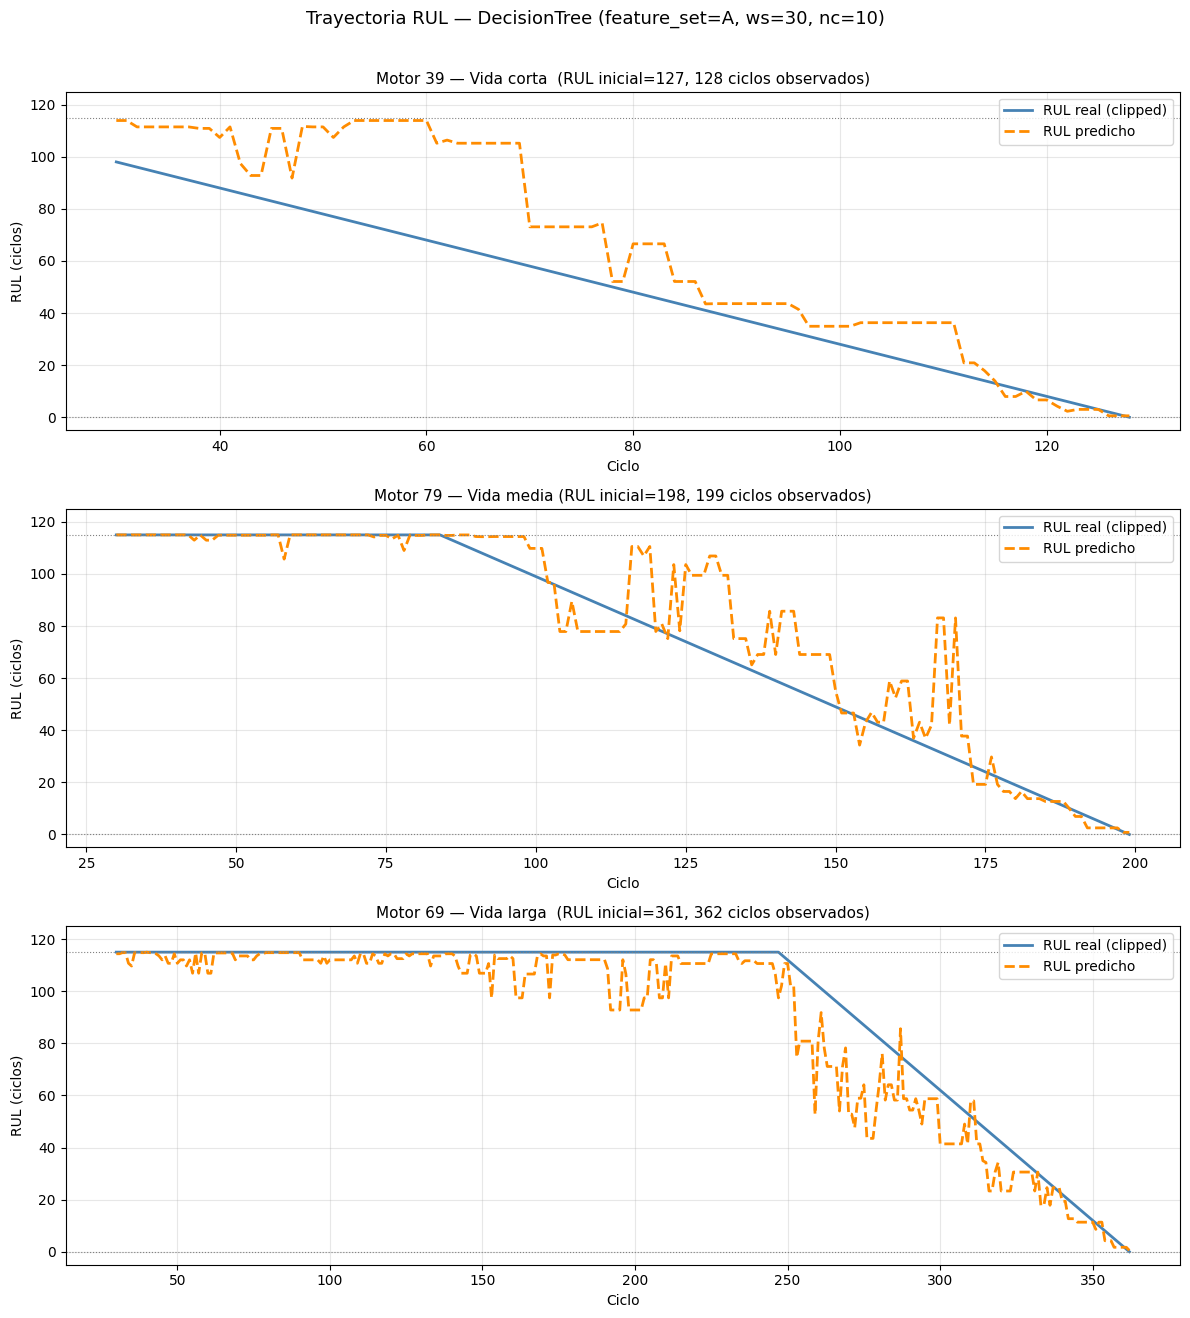

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

motores = [
    (39, 'Vida corta  (RUL inicial=127, 128 ciclos observados)'),
    (79, 'Vida media (RUL inicial=198, 199 ciclos observados)'),
    (69, 'Vida larga  (RUL inicial=361, 362 ciclos observados)'),
]

fig, axes = plt.subplots(3, 1, figsize=(12, 13))

for ax, (motor_id, titulo) in zip(axes, motores):
    df_m = pd.read_csv(f'data/clean/data_motor_{motor_id}.csv')
    df_m.insert(0, 'unit_number', motor_id)
    X_m = df_m.drop(columns=['RUL'])

    _, _, t_stop_m, _, _ = predictor_dt.pipeline_.transform(X_m)
    rul_pred_m = predictor_dt.predict(X_m, return_mode='all')

    rul_real_m = np.minimum(
        df_m['RUL'].values[predictor_dt.window_size - 1:],
        predictor_dt.clipping_threshold,
    )

    ax.plot(t_stop_m, rul_real_m, label='RUL real (clipped)', color='steelblue',  linewidth=2)
    ax.plot(t_stop_m, rul_pred_m, label='RUL predicho',       color='darkorange', linewidth=2, linestyle='--')
    ax.axhline(y=0,                           color='gray', linewidth=0.8, linestyle=':')
    ax.axhline(y=predictor_dt.clipping_threshold, color='gray', linewidth=0.8, linestyle=':')

    ax.set_title(f'Motor {motor_id} — {titulo}', fontsize=11)
    ax.set_xlabel('Ciclo')
    ax.set_ylabel('RUL (ciclos)')
    ax.set_ylim(-5, predictor_dt.clipping_threshold + 10)
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)

plt.suptitle('Trayectoria RUL — DecisionTree (feature_set=A, ws=30, nc=10)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()